# BMDS2003 Data Science — Modelling
## 5.2 Decision Tree Classifier
**Target variable:** EngagementLevel (Low / Medium / High)  
**Dataset:** processed_gaming_dataset.csv (output of Section 4.0 Data Preparation)

This notebook builds, tunes, and evaluates a Decision Tree Classifier to predict player engagement level.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
%matplotlib inline

### 2. Load the Prepared Dataset
The dataset used here is the transformed and encoded dataset produced in Section 4.0 Data Preparation, containing 26 attributes after cleaning, encoding, and feature engineering.

In [2]:
df = pd.read_csv("processed_gaming_dataset.csv")
print("Dataset shape:", df.shape)
print(df.dtypes)
df.head()

Dataset shape: (40034, 26)
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         int64
AchievementRate              float64
dtype: obje

,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup,TotalWeeklyPlayMinutes,AchievementRate
0,9000,43,16.271119,0,Medium,6,108,79,25,Medium,...,True,False,False,False,False,False,True,41-49,648,0.316456
1,9001,29,5.525961,0,Medium,5,144,11,10,Medium,...,False,True,False,False,False,False,True,21-30,720,0.909091
2,9002,22,8.223755,0,Easy,16,142,35,41,High,...,False,True,False,False,False,True,False,21-30,2272,1.171429
3,9003,35,5.265351,1,Easy,9,85,57,47,Medium,...,False,True,True,False,False,False,False,31-40,765,0.824561
4,9004,33,15.531945,0,Medium,2,131,95,37,Medium,...,False,False,True,False,False,False,False,31-40,262,0.389474


### 3. Define Features (X) and Target (y)
`PlayerID` is excluded as it holds no predictive value (Section 4.1). The raw text columns `GameDifficulty`, `AgeGroup`, and `EngagementLevel` are excluded since their encoded equivalents are already present in the dataset.

In [3]:
drop_cols = ["PlayerID", "GameDifficulty", "EngagementLevel", "EngagementLevel_enc", "AgeGroup"]
X = df.drop(columns=drop_cols)
y = df["EngagementLevel_enc"]   # 0 = Low, 1 = Medium, 2 = High

print("Feature columns used:")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("y distribution:\n", y.value_counts())

Feature columns used:
['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'GameDifficulty_enc', 'Gender_Female', 'Gender_Male', 'Location_Asia', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_Action', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'TotalWeeklyPlayMinutes', 'AchievementRate']

X shape: (40034, 21)
y distribution:
 EngagementLevel_enc
1    19374
2    10336
0    10324
Name: count, dtype: int64


### 4. Train-Test Split
A 70/30 stratified split is used, consistent with Section 4.5 Data Splitting, so that the proportion of Low, Medium, and High engagement players is preserved in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (28023, 21)
Testing set shape: (12011, 21)


### 5. Hyperparameter Tuning with GridSearchCV
`GridSearchCV` with 5-fold cross-validation is used to search over:
- **criterion**: `gini` or `entropy` — how the tree measures split quality
- **max_depth**: maximum tree depth — controls overfitting vs underfitting
- **min_samples_leaf**: minimum samples required at a leaf node — prevents unstable, overly specific leaves

In [5]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "min_samples_leaf": [1, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

best_dt = grid_search.best_estimator_

Best parameters found by GridSearchCV:
{'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 10}
Best cross-validated accuracy: 0.920458077287728


### 6. Training and Testing Accuracy

In [6]:
y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy: {test_acc*100:.2f}%")

Training Accuracy: 92.83%
Testing Accuracy: 92.21%


### 7. Confusion Matrix
The confusion matrix shows how many players from each true EngagementLevel class were correctly or incorrectly classified.

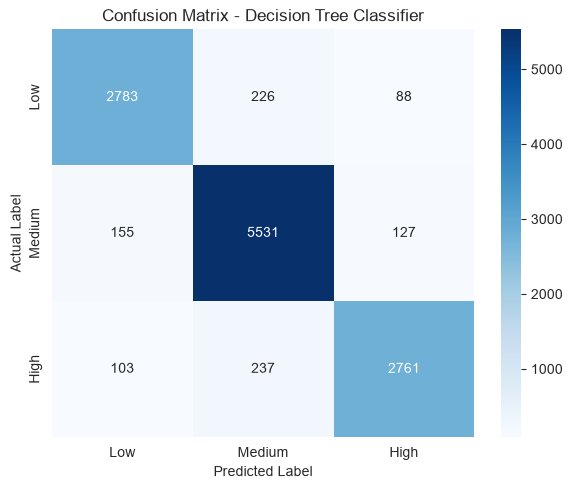

[[2783  226   88]
 [ 155 5531  127]
 [ 103  237 2761]]


In [7]:
labels = [0, 1, 2]
label_names = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("fig_dt_confusion_matrix.png", dpi=150)
plt.show()

print(cm)

### 8. Classification Report
Precision, Recall, and F1-Score are reported for each engagement class, as required by the Data Mining Success Criteria (Section 2.5).

In [8]:
report = classification_report(y_test, y_test_pred, target_names=label_names, digits=4)
print(report)

report_dict = classification_report(y_test, y_test_pred, target_names=label_names,
                                     digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("dt_classification_report.csv")
report_df

              precision    recall  f1-score   support

         Low     0.9152    0.8986    0.9068      3097
      Medium     0.9228    0.9515    0.9369      5813
        High     0.9278    0.8904    0.9087      3101

    accuracy                         0.9221     12011
   macro avg     0.9219    0.9135    0.9175     12011
weighted avg     0.9221    0.9221    0.9219     12011



,precision,recall,f1-score,support
Low,0.915159,0.898612,0.906810,3097.000000
Medium,0.922756,0.951488,0.936902,5813.000000
High,0.927755,0.890358,0.908672,3101.000000
accuracy,0.922071,0.922071,0.922071,0.922071
macro avg,0.921890,0.913486,0.917461,12011.000000
weighted avg,0.922088,0.922071,0.921854,12011.000000


### 9. ROC Curve and AUC (One-vs-Rest)
Since EngagementLevel has three classes, a One-vs-Rest ROC curve is plotted for each class to evaluate how well the model separates each class from the rest.

Macro-average AUC: 0.9444
Weighted-average AUC: 0.9455
AUC for Low: 0.9428
AUC for Medium: 0.9492
AUC for High: 0.9413


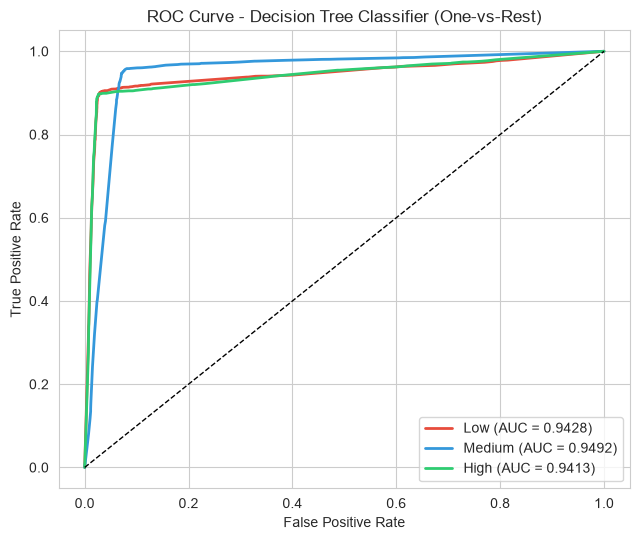

In [9]:
y_test_bin = label_binarize(y_test, classes=labels)
y_score = best_dt.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_test_bin, y_score, average="weighted", multi_class="ovr")

print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")
for i, name in enumerate(label_names):
    print(f"AUC for {name}: {roc_auc[i]:.4f}")

plt.figure(figsize=(6.5, 5.5))
colors = ["#E74C3C", "#3498DB", "#2ECC71"]
for i, name in enumerate(label_names):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{name} (AUC = {roc_auc[i]:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_dt_roc_curve.png", dpi=150)
plt.show()

### 10. Feature Importance
Feature importance shows which attributes the Decision Tree relied on most when splitting the data, and can be compared against the relationships identified earlier in Data Understanding (Section 3.9 and 3.10).

Top 10 Feature Importances:
TotalWeeklyPlayMinutes       0.890084
PlayerLevel                  0.047660
AchievementsUnlocked         0.044793
AchievementRate              0.005216
PlayTimeHours                0.004264
AvgSessionDurationMinutes    0.002473
Age                          0.002098
GameDifficulty_enc           0.000909
SessionsPerWeek              0.000538
GameGenre_Action             0.000383
dtype: float64


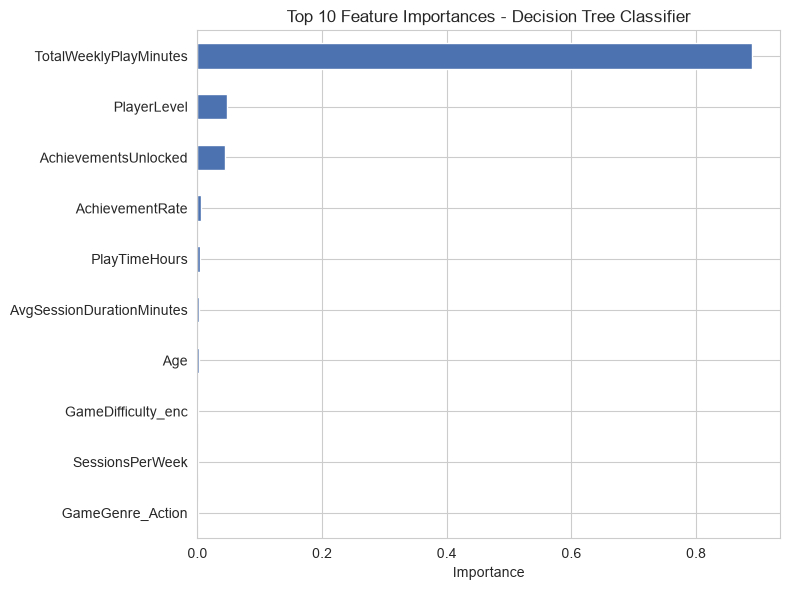

In [10]:
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Feature Importances:")
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Feature Importances - Decision Tree Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("fig_dt_feature_importance.png", dpi=150)
plt.show()

### 11. Visualise the Decision Tree (Top 3 Levels)
The full tree is too large to display readably, so only the top 3 levels are shown to illustrate how the model splits the data.

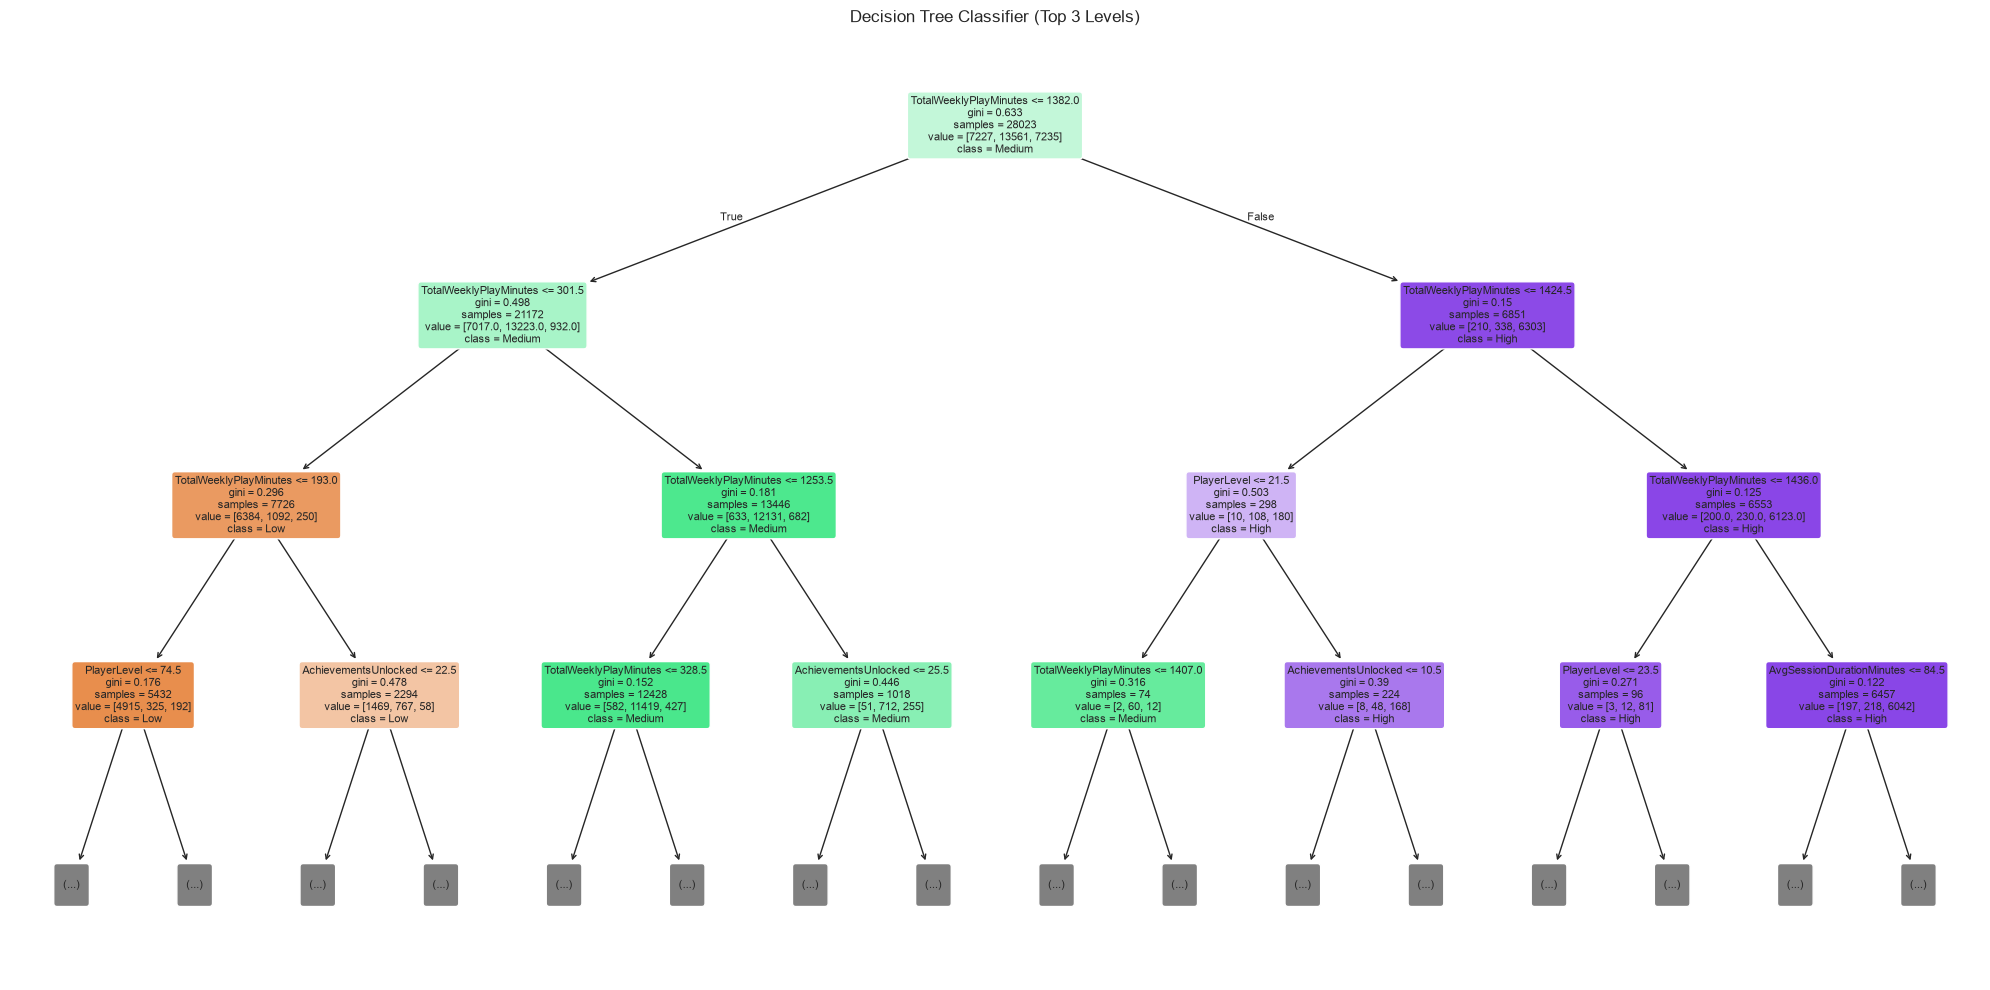

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, max_depth=3, feature_names=X.columns, class_names=label_names,
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Classifier (Top 3 Levels)")
plt.tight_layout()
plt.savefig("fig_dt_tree_plot.png", dpi=150)
plt.show()

### 12. Summary

| Metric | Value |
|---|---|
| Best Criterion | Gini |
| Best max_depth | 12 |
| Best min_samples_leaf | 10 |
| Training Accuracy | 92.83% |
| Testing Accuracy | 92.21% |
| Macro-average AUC | 0.9444 |
| Most important feature | TotalWeeklyPlayMinutes (~89%) |

The Decision Tree Classifier exceeds the 80% accuracy target defined in the Data Mining Success Criteria (Section 2.5), with a small train/test accuracy gap indicating good generalisation. The feature importance results confirm the behavioural patterns observed earlier in Data Understanding: session-related features (TotalWeeklyPlayMinutes, PlayerLevel, AchievementsUnlocked) dominate the model's decisions, while demographic and categorical attributes contribute minimally.